# ClothSA — T5-base Aspect-Based Sentiment Analysis (Updated)
Additions in this version:
- Slang / informal-text normalization + slang-aware aspect keywords
- Dataset scaled to **100,000** balanced samples
- Data split into **train / validation / test** sets
- Checkpointing (auto-resume if training is interrupted)
- Full evaluation: aspect-level accuracy, precision/recall/F1
- Loss curves & accuracy curves
- Confusion matrices per aspect-sentiment


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install transformers datasets pandas torch sentencepiece scikit-learn matplotlib seaborn -q

## 1. Load data

In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/cloth/amazon-fashion-800k+-user-reviews-dataset.csv"

df = pd.read_csv(file_path)
df.head()
print(df.shape)
print(df['target'].value_counts())
print(df[['text', 'target']].head())

(867310, 11)
target
-1    346924
 1    346924
 0    173462
Name: count, dtype: int64
                                                text  target
0  I was looking for 5 pair and only received 2 p...      -1
1  Just donÃ¢ÂÂt. These things fell apart after...      -1
2                        Retuned is too small for me      -1
3  This product came with the sleeves turned insi...      -1
4  Worn once and several places at seams have com...      -1


## 2. Clean text + slang normalization
Amazon reviews are full of informal shorthand (`gr8`, `luv`, `def`, `2 small`, emojis-as-words, etc). Normalizing slang before feeding text into the model helps the tokenizer see consistent, real words instead of splitting slang into meaningless subword pieces.

In [ ]:
import re

# Common review/chat slang -> normalized word.
# Extend this dictionary any time you spot new slang in your dataset.
SLANG_DICT = {
    r"\bgr8\b": "great",
    r"\bgreat8\b": "great",
    r"\bluv\b": "love",
    r"\blovee+\b": "love",
    r"\bdef\b": "definitely",
    r"\bdefo\b": "definitely",
    r"\bpls\b": "please",
    r"\bplz\b": "please",
    r"\bthx\b": "thanks",
    r"\btnx\b": "thanks",
    r"\bty\b": "thank you",
    r"\bu\b": "you",
    r"\bur\b": "your",
    r"\br\b": "are",
    r"\bb4\b": "before",
    r"\b2day\b": "today",
    r"\b2nite\b": "tonight",
    r"\bcuz\b": "because",
    r"\bcoz\b": "because",
    r"\bbc\b": "because",
    r"\bfab\b": "fabulous",
    r"\bfab+ric\b": "fabric",
    r"\bcomfy\b": "comfortable",
    r"\buncomfy\b": "uncomfortable",
    r"\blegit\b": "genuine",
    r"\bmeh\b": "mediocre",
    r"\bmehh+\b": "mediocre",
    r"\bsuper cute\b": "very attractive",
    r"\bcute\b": "attractive",
    r"\bawsome\b": "awesome",
    r"\bawesomee+\b": "awesome",
    r"\bnicee+\b": "nice",
    r"\bgoodd+\b": "good",
    r"\bbaddd+\b": "bad",
    r"\bworstt+\b": "worst",
    r"\bmoneyy?'?s? worth\b": "worth the money",
    r"\bruns big\b": "size is larger than expected",
    r"\bruns small\b": "size is smaller than expected",
    r"\btts\b": "true to size",
    r"\bqc\b": "quality control",
    r"\basap\b": "as soon as possible",
    r"\bimo\b": "in my opinion",
    r"\bimho\b": "in my honest opinion",
    r"\btbh\b": "to be honest",
    r"\bngl\b": "not going to lie",
    r"\b10\/10\b": "excellent",
    r"\b5\s*stars?\b": "excellent",
    r"\bwont\b": "will not",
    r"\bdont\b": "do not",
    r"\bcant\b": "cannot",
    r"\bdidnt\b": "did not",
    r"\bdoesnt\b": "does not",
    r"\bisnt\b": "is not",
    r"\bnvm\b": "never mind",
}
SLANG_PATTERNS = [(re.compile(p, flags=re.IGNORECASE), r) for p, r in SLANG_DICT.items()]

def normalize_slang(text: str) -> str:
    for pattern, replacement in SLANG_PATTERNS:
        text = pattern.sub(replacement, text)
    return text

def clean_text(text):
    text = str(text)
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)   # remove non-ASCII (fixes DonÃ¢ etc)
    text = normalize_slang(text)                   # expand slang/abbreviations
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Keep only needed columns
df = df[['text', 'target']].dropna()

df['text'] = df['text'].apply(clean_text)

# Remove very short reviews
df = df[df['text'].str.len() > 20]

# Map target to sentiment label
sentiment_map = {1: 'positive', 0: 'neutral', -1: 'negative'}
df['sentiment'] = df['target'].map(sentiment_map)

print(df['sentiment'].value_counts())
print(f"Total usable reviews: {len(df)}")

sentiment
negative    321072
positive    302378
neutral     161921
Name: count, dtype: int64
Total usable reviews: 785371


## 3. Aspect extraction (slang-aware keywords)
Keyword lists now include common informal synonyms so aspects are still detected in casual reviews.

In [ ]:
# Clothing-specific aspect keywords (expanded with slang/informal synonyms)
ASPECT_KEYWORDS = {
    'fabric':    ['fabric', 'material', 'cloth', 'cotton', 'silk', 'polyester', 'linen',
                  'texture', 'soft', 'rough', 'thin', 'thick', 'fabulous fabric'],
    'fit':       ['fit', 'fitted', 'fitting', 'loose', 'tight', 'snug', 'baggy', 'oversized',
                  'true to size', 'size is larger than expected', 'size is smaller than expected'],
    'size':      ['size', 'sizing', 'small', 'large', 'medium', 'runs small', 'runs large',
                  'true to size', 'tts'],
    'stitching': ['stitch', 'stitching', 'seam', 'seams', 'sewing', 'thread', 'hem', 'hemline'],
    'color':     ['color', 'colour', 'faded', 'vibrant', 'bright', 'dark', 'dye', 'print', 'pattern'],
    'design':    ['design', 'style', 'look', 'appearance', 'aesthetic', 'beautiful', 'ugly',
                  'elegant', 'pretty', 'attractive', 'cute'],
    'quality':   ['quality', 'durable', 'durability', 'cheap', 'premium', 'well made',
                  'poorly made', 'genuine', 'mediocre', 'quality control'],
    'delivery':  ['delivery', 'shipping', 'arrived', 'package', 'packaging', 'shipped',
                  'as soon as possible'],
    'price':     ['price', 'cost', 'worth', 'expensive', 'cheap', 'affordable', 'value',
                  'worth the money'],
    'zipper':    ['zipper', 'zip', 'button', 'buttons', 'closure', 'snap'],
    'comfort':   ['comfort', 'comfortable', 'uncomfortable', 'cozy', 'itchy', 'breathable'],
    'length':    ['length', 'long', 'short', 'maxi', 'mini', 'crop', 'ankle'],
}

def extract_aspects_from_text(text: str, sentiment: str) -> str:
    """
    Finds which aspects are mentioned in the review
    and assigns the overall sentiment to each found aspect.
    Returns: 'fabric: positive, size: negative' etc.
    """
    text_lower = text.lower()
    found_aspects = []

    for aspect, keywords in ASPECT_KEYWORDS.items():
        for keyword in keywords:
            if keyword in text_lower:
                found_aspects.append(aspect)
                break  # only add each aspect once

    if not found_aspects:
        return None  # skip reviews with no detectable aspects

    pairs = [f"{aspect}: {sentiment}" for aspect in found_aspects]
    return ", ".join(pairs)

df['output'] = df.apply(
    lambda row: extract_aspects_from_text(row['text'], row['sentiment']),
    axis=1
)

df = df.dropna(subset=['output'])

print(f"Reviews with aspects found: {len(df)}")
print("\nSample outputs:")
print(df[['text', 'output']].head(10).to_string())

Reviews with aspects found: 673255

Sample outputs:
                                                                                                                                                                                                                                        text                                                             output
0   I was looking for 5 pair and only received 2 pair tho I paid for 5 pair and the two pair was late I'm a prime member and feel like I was cheated if my math serve me correct I'm still short 3 pair of panties that were listed as prime                                 design: negative, length: negative
1                                                                                                                            Just don t. These things fell apart after the first wash and are SO uncomfortable. Buy literally anything else!                                fabric: negative, comfort: negative
2                                   

## 4. Balanced sampling — scaled to 100,000 rows


In [ ]:
# Take 100k samples, balanced across sentiments
TOTAL_SAMPLES = 100_000
sample_per_class = TOTAL_SAMPLES // 3   # ~33,333 per class

def sample_class(cls):
    available = df[df['sentiment'] == cls]
    n = min(sample_per_class, len(available))
    if n < sample_per_class:
        print(f"WARNING: only {n} '{cls}' rows available (wanted {sample_per_class}). "
              f"Consider allowing replacement or loosening aspect filtering.")
    return available.sample(n, random_state=42)

df_balanced = pd.concat([
    sample_class('positive'),
    sample_class('negative'),
    sample_class('neutral'),
]).sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle

print(f"Final dataset size: {len(df_balanced)}")
print(df_balanced['sentiment'].value_counts())


Final dataset size: 99999
sentiment
positive    33333
neutral     33333
negative    33333
Name: count, dtype: int64


## 5. Train / validation / test split (kept as raw dataframes too — needed later for confusion matrices)


In [ ]:
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer
from datasets import Dataset

MODEL_NAME = "t5-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

MAX_INPUT_LENGTH = 128
MAX_TARGET_LENGTH = 64

# 70% train, 15% validation, 15% test (stratified by sentiment)
train_df, temp_df = train_test_split(
    df_balanced, test_size=0.30, random_state=42, stratify=df_balanced['sentiment']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df['sentiment']
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

def preprocess(examples):
    inputs  = [f"aspect-sentiment analysis: {text}" for text in examples["text"]]
    targets = examples["output"]

    # No static padding here — DataCollatorForSeq2Seq (Cell 16) pads dynamically per
    # batch instead. Padding every example to a fixed 128/64 tokens regardless of actual
    # length wastes real compute on pad tokens; dynamic per-batch padding avoids that.
    model_inputs = tokenizer(
        inputs,
        max_length=MAX_INPUT_LENGTH,
        truncation=True
    )
    labels = tokenizer(
        targets,
        max_length=MAX_TARGET_LENGTH,
        truncation=True
    )
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

train_dataset = Dataset.from_pandas(train_df[['text', 'output']])
val_dataset   = Dataset.from_pandas(val_df[['text', 'output']])
test_dataset  = Dataset.from_pandas(test_df[['text', 'output']])

train_dataset = train_dataset.map(preprocess, batched=True, remove_columns=["text", "output"])
val_dataset   = val_dataset.map(preprocess, batched=True, remove_columns=["text", "output"])
test_dataset  = test_dataset.map(preprocess, batched=True, remove_columns=["text", "output"])

dataset = {"train": train_dataset, "val": val_dataset, "test": test_dataset}

print(f"Train: {len(dataset['train'])}, Val: {len(dataset['val'])}, Test: {len(dataset['test'])}")

# --- Truncation check: if any target strings actually need more than MAX_TARGET_LENGTH
# tokens, they're being silently cut off during training — the model would never learn to
# predict the truncated trailing aspects, which directly feeds a "missing" problem at the root.
raw_target_lengths = [len(tokenizer(t, truncation=False)["input_ids"]) for t in train_df["output"]]
n_truncated = sum(1 for l in raw_target_lengths if l > MAX_TARGET_LENGTH)
print(f"\nTarget length check: max needed = {max(raw_target_lengths)} tokens, "
      f"MAX_TARGET_LENGTH = {MAX_TARGET_LENGTH}")
print(f"{n_truncated}/{len(raw_target_lengths)} training targets ({n_truncated/len(raw_target_lengths):.2%}) "
      f"are being truncated.")
if n_truncated > 0:
    print("Consider raising MAX_TARGET_LENGTH to avoid training the model to drop trailing aspects.")


config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

Map:   0%|          | 0/69999 [00:00<?, ? examples/s]

Map:   0%|          | 0/15000 [00:00<?, ? examples/s]

Map:   0%|          | 0/15000 [00:00<?, ? examples/s]

Train: 69999, Val: 15000, Test: 15000

Target length check: max needed = 45 tokens, MAX_TARGET_LENGTH = 64
0/69999 training targets (0.00%) are being truncated.


## 6. Metrics function
Parses the generated `"aspect: sentiment, ..."` strings and scores per-aspect sentiment accuracy, plus overall exact-match accuracy. These numbers get logged every eval step, which is what powers the accuracy curve later.

In [ ]:
import numpy as np

def parse_output(text: str) -> dict:
    pairs = {}
    for part in text.split(","):
        part = part.strip()
        if ":" in part:
            aspect, sentiment = part.split(":", 1)
            pairs[aspect.strip().lower()] = sentiment.strip().lower()
    return pairs

def compute_metrics(eval_preds):
    preds, labels = eval_preds
    if isinstance(preds, tuple):
        preds = preds[0]

    preds = np.where(preds != -100, preds, tokenizer.pad_token_id)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)

    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    correct_aspects, total_aspects, exact_matches = 0, 0, 0
    for pred, label in zip(decoded_preds, decoded_labels):
        pred_pairs = parse_output(pred)
        true_pairs = parse_output(label)

        if pred_pairs == true_pairs:
            exact_matches += 1

        for aspect, sentiment in true_pairs.items():
            total_aspects += 1
            if pred_pairs.get(aspect) == sentiment:
                correct_aspects += 1

    aspect_accuracy = correct_aspects / total_aspects if total_aspects else 0.0
    exact_match_accuracy = exact_matches / len(decoded_labels) if decoded_labels else 0.0

    return {
        "aspect_accuracy": aspect_accuracy,
        "exact_match_accuracy": exact_match_accuracy,
    }

## 7. Model + training args (with checkpointing)
`save_strategy="steps"` + `save_total_limit` gives regular checkpoints without filling up disk. If Colab disconnects mid-training, re-run this notebook from the top and the training cell will auto-resume from the last checkpoint instead of starting over.

In [ ]:
from transformers import (
    T5ForConditionalGeneration,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq,
    TrainerCallback,
    EarlyStoppingCallback
)
from transformers.trainer_utils import get_last_checkpoint
import torch, os, math

OUTPUT_DIR = "/content/drive/MyDrive/cloth/t5base_clothing"  # on Drive so checkpoints survive disconnects

model = T5ForConditionalGeneration.from_pretrained(MODEL_NAME)

# --- Safety net: T5 + fp16 is known to overflow/NaN mid-training. This callback
# stops training immediately (instead of silently burning hours on a dead model)
# the moment a NaN/Inf loss shows up.
class StopOnNaNCallback(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        loss = (logs or {}).get("loss")
        if loss is not None and (math.isnan(loss) or math.isinf(loss)):
            print(f"\n!!! NaN/Inf loss detected at step {state.global_step} — stopping training.")
            print("This almost always means fp16 overflowed on T5. Re-run with fp16=False "
                  "(or bf16=True on Ampere+ GPUs) and/or a lower learning rate.")
            control.should_training_stop = True
        return control

# bf16 is numerically safe for T5 (same dynamic range it was pretrained in) and is
# available on Ampere+ GPUs (A100/L4/RTX30xx+). fp16 is NOT safe for T5 — it overflows.
use_bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()

training_args = Seq2SeqTrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=5,          # ceiling, not a target — EarlyStoppingCallback below will stop sooner if it plateaus
    per_device_train_batch_size=16,  # dynamic padding (Cell 12) frees up memory vs static
                                      # padding, so we can afford a bigger batch than before.
                                      # Drop to 8 (and bump gradient_accumulation_steps to 4)
                                      # if you hit a CUDA OOM on your T4.
    gradient_accumulation_steps=2,   # 16 * 2 = effective batch size 32, same as your original setup
    per_device_eval_batch_size=8,
    eval_accumulation_steps=8,       # stream eval preds to CPU incrementally, avoids an eval-time OOM
    # group_by_length=True was dropped — your installed transformers version doesn't support
    # it as a Seq2SeqTrainingArguments field (TypeError: unexpected keyword argument). Not
    # essential — the dynamic padding fix in Cell 12 is the bigger speed win and still applies.
    learning_rate=1e-4,          # was 3e-4 — that value is tuned for Adafactor, too hot for AdamW+T5
    max_grad_norm=1.0,           # explicit gradient clipping to catch early blow-ups
    warmup_steps=100,
    weight_decay=0.01,
    predict_with_generate=True,
    eval_strategy="steps",
    eval_steps=1000,
    save_strategy="steps",
    save_steps=1000,
    save_total_limit=3,             # keep only the 3 most recent checkpoints
    load_best_model_at_end=True,
    metric_for_best_model="aspect_accuracy",
    greater_is_better=True,
    logging_steps=50,
    fp16=False,                  # <-- THE FIX: fp16 overflows on T5's internal activations
    bf16=use_bf16,               # use bf16 instead when the GPU supports it (safe + fast)
    report_to="none"
)

data_collator = DataCollatorForSeq2Seq(tokenizer, model=model, padding=True)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["val"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[
        StopOnNaNCallback(),
        # Stops training if aspect_accuracy hasn't improved for 3 consecutive evals (3000 steps).
        # load_best_model_at_end=True (already set above) guarantees you still end up with the
        # best checkpoint seen, not just whichever one happened to be last.
        EarlyStoppingCallback(early_stopping_patience=3),
    ],
)

# Resume automatically if a checkpoint already exists in OUTPUT_DIR.
last_checkpoint = None
if os.path.isdir(OUTPUT_DIR):
    last_checkpoint = get_last_checkpoint(OUTPUT_DIR)
    if last_checkpoint:
        print(f"Found existing checkpoint, will resume from: {last_checkpoint}")

# Record a genuine step-0 baseline (loss/accuracy of the untrained model) so the loss
# and accuracy curves both truly start from the same point, instead of the eval line only
# beginning at step 1000 like in the earlier run.
if last_checkpoint is None:
    print("Running baseline eval before training starts...")
    baseline_metrics = trainer.evaluate()
    baseline_metrics["step"] = 0
    baseline_metrics["epoch"] = 0.0
    trainer.state.log_history.insert(0, baseline_metrics)
    print("Baseline (step 0):", baseline_metrics)

print("Starting training...")
trainer.train(resume_from_checkpoint=last_checkpoint)
print("Training complete!")

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Found existing checkpoint, will resume from: /content/drive/MyDrive/cloth/t5base_clothing/checkpoint-10000
Starting training...


[transformers] There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


Step,Training Loss,Validation Loss,Aspect Accuracy,Exact Match Accuracy
10940,0.135891,0.089335,0.687792,0.667867


/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:1616: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] Could not locate the best model at /content/drive/MyDrive/cloth/t5base_clothing/checkpoint-6000/pytorch_model.bin, if you are running a distributed training on multiple nodes, you should activate `--save_on_each_node`.


Training complete!


## 8. Loss curves & accuracy curves

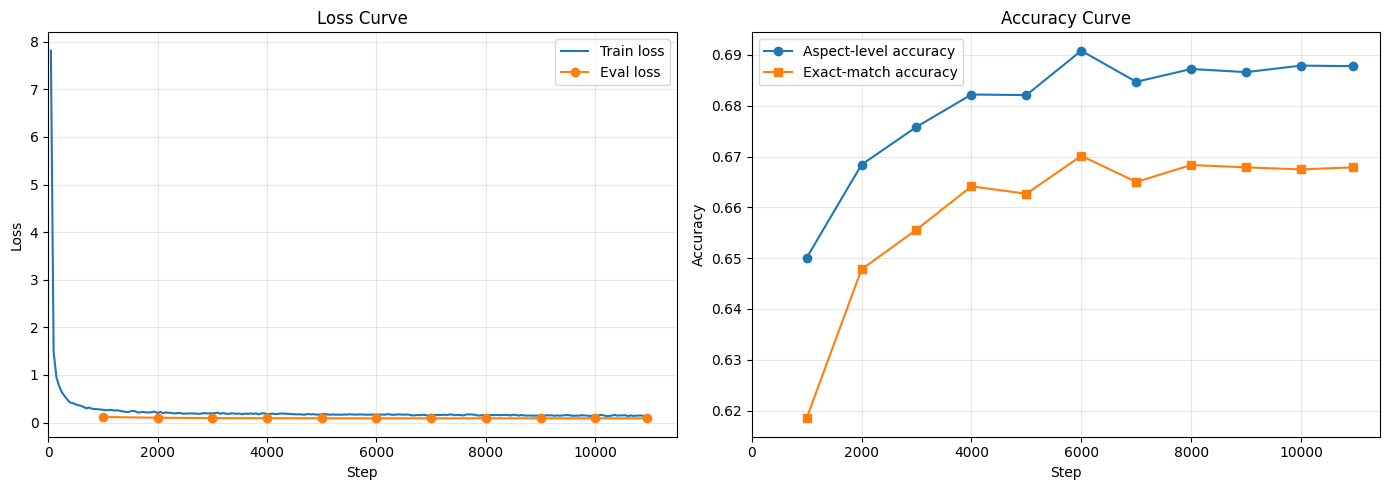

In [ ]:
import matplotlib.pyplot as plt

history = trainer.state.log_history

train_steps, train_loss = [], []
eval_steps, eval_loss = [], []
eval_aspect_acc, eval_exact_acc = [], []

for entry in history:
    if "loss" in entry and "eval_loss" not in entry:
        train_steps.append(entry["step"])
        train_loss.append(entry["loss"])
    if "eval_loss" in entry:
        eval_steps.append(entry["step"])
        eval_loss.append(entry["eval_loss"])
        eval_aspect_acc.append(entry.get("eval_aspect_accuracy"))
        eval_exact_acc.append(entry.get("eval_exact_match_accuracy"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(train_steps, train_loss, label="Train loss")
axes[0].plot(eval_steps, eval_loss, label="Eval loss", marker="o")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Curve")
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_xlim(left=0)

# Accuracy curve
axes[1].plot(eval_steps, eval_aspect_acc, label="Aspect-level accuracy", marker="o")
axes[1].plot(eval_steps, eval_exact_acc, label="Exact-match accuracy", marker="s")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy Curve")
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_xlim(left=0)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

## 9. Confusion matrices
One confusion matrix per aspect (predicted sentiment vs. true sentiment on the held-out test set), plus an overall aggregated confusion matrix and a classification report (precision/recall/F1).

[transformers] Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs

Aspect detection rate: 36094/37042 = 97.44%
(i.e. how often the model mentions a true aspect at all, regardless of sentiment)

Sentiment accuracy (given aspect was detected): 26508/36094 = 73.44%

Overall sentiment classification report:

              precision    recall  f1-score   support

    positive       0.84      0.79      0.81     12343
     neutral       0.63      0.63      0.63     12771
    negative       0.75      0.74      0.75     11928
     missing       0.00      0.00      0.00         0

    accuracy                           0.72     37042
   macro avg       0.55      0.54      0.55     37042
weighted avg       0.74      0.72      0.73     37042



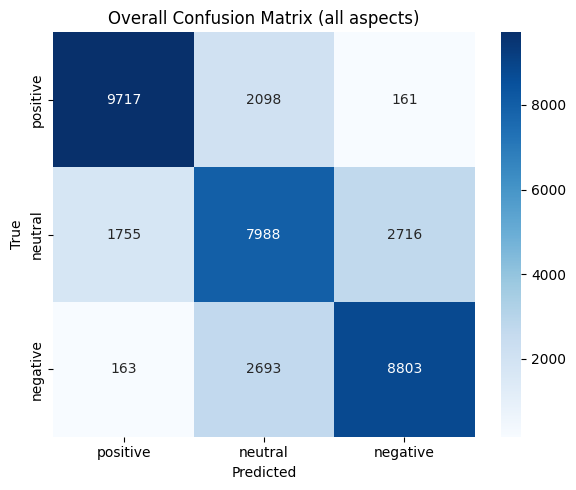

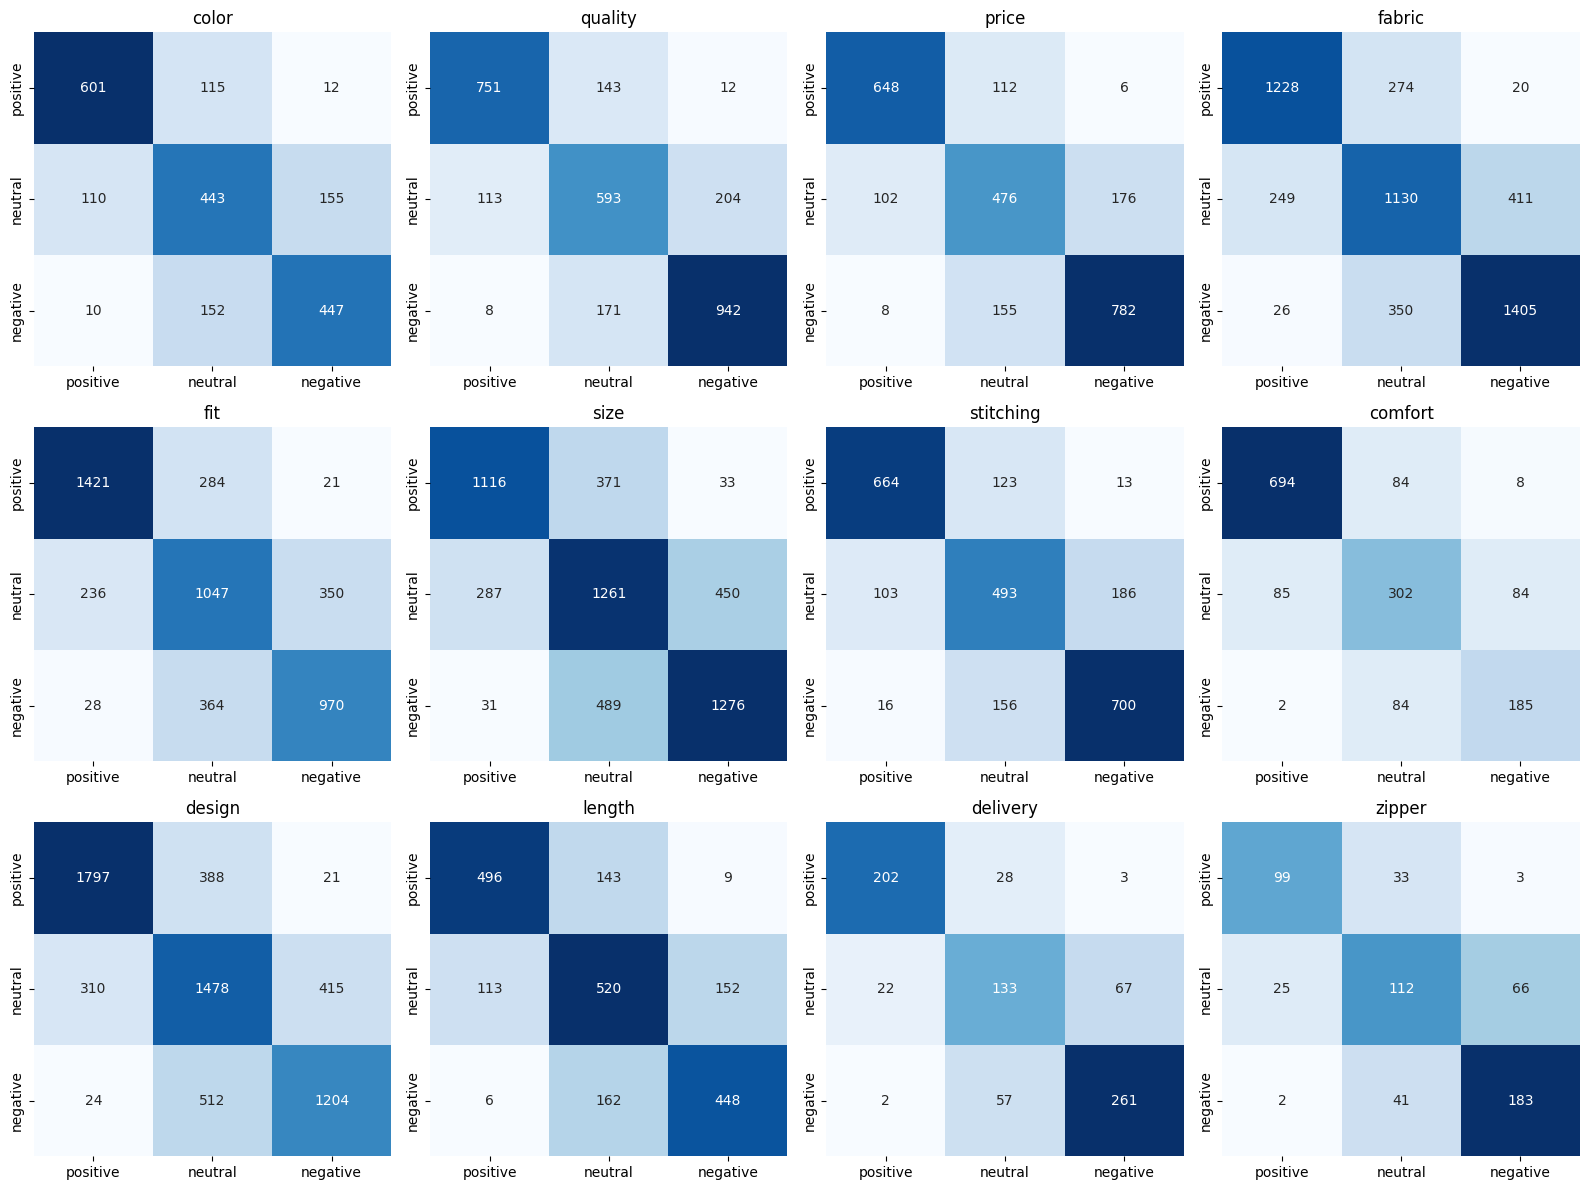

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import seaborn as sns

model.eval()
device = model.device
LABELS = ["positive", "neutral", "negative"]

def generate_batch(texts, batch_size=32):
    outputs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        inputs = tokenizer(
            [f"aspect-sentiment analysis: {t}" for t in batch],
            return_tensors="pt", max_length=MAX_INPUT_LENGTH,
            padding=True, truncation=True
        ).to(device)
        with torch.no_grad():
            gen = model.generate(
                **inputs, max_new_tokens=MAX_TARGET_LENGTH, num_beams=4, early_stopping=True
            )
        outputs.extend(tokenizer.batch_decode(gen, skip_special_tokens=True))
    return outputs

test_texts = test_df['text'].tolist()
test_true_outputs = test_df['output'].tolist()

predicted_outputs = generate_batch(test_texts)

all_true, all_pred, per_aspect = [], [], {}

for true_str, pred_str in zip(test_true_outputs, predicted_outputs):
    true_pairs = parse_output(true_str)
    pred_pairs = parse_output(pred_str)
    for aspect, true_sent in true_pairs.items():
        pred_sent = pred_pairs.get(aspect, "missing")
        if true_sent not in LABELS:
            continue
        all_true.append(true_sent)
        all_pred.append(pred_sent if pred_sent in LABELS else "missing")
        per_aspect.setdefault(aspect, {"true": [], "pred": []})
        per_aspect[aspect]["true"].append(true_sent)
        per_aspect[aspect]["pred"].append(pred_sent if pred_sent in LABELS else "missing")

# --- Aspect-detection rate (separate from sentiment classification) ---
total_true_aspects = len(all_true)
detected = sum(1 for p in all_pred if p != "missing")
print(f"Aspect detection rate: {detected}/{total_true_aspects} = {detected/total_true_aspects:.2%}")
print("(i.e. how often the model mentions a true aspect at all, regardless of sentiment)\n")

# Sentiment accuracy conditional on the aspect actually being detected:
detected_true  = [t for t, p in zip(all_true, all_pred) if p != "missing"]
detected_pred  = [p for p in all_pred if p != "missing"]
if detected_true:
    correct_given_detected = sum(t == p for t, p in zip(detected_true, detected_pred))
    print(f"Sentiment accuracy (given aspect was detected): "
          f"{correct_given_detected}/{len(detected_true)} = {correct_given_detected/len(detected_true):.2%}\n")

# --- Overall classification report (kept as-is, "missing" still reported here) ---
report_labels = LABELS + ["missing"]
print("Overall sentiment classification report:\n")
print(classification_report(all_true, all_pred, labels=report_labels, zero_division=0))

# --- Overall confusion matrix (only plot LABELS, exclude "missing" rows/cols) ---
cm = confusion_matrix(detected_true, detected_pred, labels=LABELS)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=LABELS, yticklabels=LABELS, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Overall Confusion Matrix (all aspects)")
plt.tight_layout()
plt.savefig("confusion_matrix_overall.png", dpi=150)
plt.show()

# --- Per-aspect confusion matrices (only plot LABELS, exclude "missing" rows/cols) ---
aspects_with_data = [a for a, v in per_aspect.items() if len(v["true"]) >= 5]
n_aspects = len(aspects_with_data)
n_cols = 4
n_rows = -(-n_aspects // n_cols)  # ceil

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = axes.flatten() if n_aspects > 1 else [axes]

for i, aspect in enumerate(aspects_with_data):
    y_true = per_aspect[aspect]["true"]
    y_pred = per_aspect[aspect]["pred"]
    y_true_f = [t for t, p in zip(y_true, y_pred) if p != "missing"]
    y_pred_f = [p for p in y_pred if p != "missing"]
    cm_a = confusion_matrix(y_true_f, y_pred_f, labels=LABELS)
    sns.heatmap(cm_a, annot=True, fmt="d", cmap="Blues",
                xticklabels=LABELS, yticklabels=LABELS, ax=axes[i], cbar=False)
    axes[i].set_title(aspect)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

for j in range(len(aspects_with_data), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig("confusion_matrix_per_aspect.png", dpi=150)
plt.show()

## 10. Quick sanity test on hand-written reviews

In [ ]:
model.eval()

test_reviews = [
    "the fabric is very soft but the size runs too small",
    "zipper broke after one use, terrible quality",
    "beautiful design and perfect fit, fast delivery",
    "color faded after first wash and stitching came apart",
    "comfortable material but a bit overpriced",
    "gr8 fit, luv the fabric, def buying again",       # slang test
    "meh quality tbh, wasnt worth the money imo",       # slang test
]

print("Testing model predictions:\n")
for review in test_reviews:
    inputs = tokenizer(
        f"aspect-sentiment analysis: {clean_text(review)}",
        return_tensors="pt",
        max_length=128,
        truncation=True
    ).to(model.device)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=64,
            num_beams=4,
            do_sample=False,
            no_repeat_ngram_size=3,
            repetition_penalty=2.5,
            early_stopping=True
        )

    result = tokenizer.decode(output[0], skip_special_tokens=True)
    print(f"Review : {review}")
    print(f"Output : {result}")
    print("-" * 60)

[transformers] Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Testing model predictions:



[transformers] Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Review : the fabric is very soft but the size runs too small
Output : fabric: neutral, size: neutral
------------------------------------------------------------


[transformers] Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Review : color faded after first wash and stitching came apart
Output : stitching: negative, color: negative
------------------------------------------------------------


[transformers] Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Review : comfortable material but a bit overpriced
Output : fabric: favorable, price: positive, comfort: positive
------------------------------------------------------------


[transformers] Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Review : gr8 fit, luv the fabric, def buying again
Output : fabric: positive, fit: positive
------------------------------------------------------------
Review : meh quality tbh, wasnt worth the money imo
Output : quality: neutral, price: neutral
------------------------------------------------------------


## 11. Save model + checkpoints, zip and download

In [ ]:
import shutil
from google.colab import files

FINAL_DIR = "./t5base_clothing_final"
model.save_pretrained(FINAL_DIR)
tokenizer.save_pretrained(FINAL_DIR)

shutil.make_archive("t5base_final", "zip", FINAL_DIR)
files.download("t5base_final.zip")

print("Downloaded final model.")
print(f"All training checkpoints remain saved under: {OUTPUT_DIR}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded final model.
All training checkpoints remain saved under: /content/drive/MyDrive/cloth/t5base_clothing
